<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>EasyVisa: Visa Approval Prediction Using Ensemble Machine Learning Models</font></center>
<center><font size=6>UT Austin AIML Program — Ensemble Techniques & Model Tuning</font></center>
<center><font size=6><b>Prepared by: Usiere Uko</b></font></center>

<div align="center">

<img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1200"
width="600"/>

</div>

# **Problem Statement**

## Context

## Problem Statement

Organizations in the United States face increasing demand for skilled labor and often rely on foreign workers to address workforce shortages. Visa approval decisions involve evaluating multiple applicant and employer-related factors, making the process complex and time-consuming.

EasyVisa aims to leverage machine learning techniques to predict visa approval outcomes and identify the key drivers influencing certification decisions.

## Objective

The objective of this project is to build and evaluate ensemble machine learning models that can:

- Predict visa approval outcomes
- Identify important factors influencing approvals
- Support faster and more data-driven decision-making
- Provide business insights and recommendations

## Data Description

The dataset contains demographic, educational, employment, and company-related information for visa applicants and employers, including factors such as education level, work experience, prevailing wage, company size, employment region, and visa case status.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 scipy==1.16.2 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 37.8 MB/s eta 0:00:00


In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To remove the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
visa = pd.read_csv("/content/drive/MyDrive/EasyVisa.csv") ##  Reading the data

In [ ]:
# copying data to another variable to avoid any changes to original data
data = visa.copy()

# **Overview of the Dataset**

## View the first and last 5 rows of the dataset

In [ ]:
data.head() ##  To view top 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail() ##  To view last 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


## Understand the shape of the dataset

In [ ]:
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.") ##  To view dimensions of the data

The dataset has 25480 rows and 12 columns.


## Check the data types of the columns for the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


*   Only 3 variables are numerical rest all are object types.
*   All columns have 25480 non-null values i.e. no column has a missing value



## Checking for duplicate values

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)



*   There are no duplicate calues



## Checking for missing values

In [ ]:
print("Number of missing values in each column:\n")
print(data.isnull().sum())

Number of missing values in each column:

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


* There are no missing values in the dataset




# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

#### Let's check the statistical summary of the data

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


*   no_of_employees: Company sizes vary significantly across the dataset, with a large spread in employee counts and possible outliers or invalid entries present.
*   yr_of_estab: Most companies were established between the late 1900s and early 2000s, indicating that many employers are relatively established organizations.
*   prevailing_wage: Prevailing wages show substantial variation across applications, suggesting differences in job roles, industries, and regions.








#### Fixing the negative values in number of employees columns

In [ ]:
data.loc[data["no_of_employees"] < 0].shape

(33, 12)

* We will consider the 33 observations as data entry errors and take the absolute values for this column.

In [ ]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])

#### Let's check the count of each unique category in each of the categorical variables

In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts()) ##  To print the count of each unique value in each column
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [ ]:
# checking the number of unique values
data["case_id"].nunique()

25480

In [ ]:
data.drop(["case_id"], axis=1, inplace=True)

## Univariate Analysis

### Functions required for EDA

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Observations on education of employee

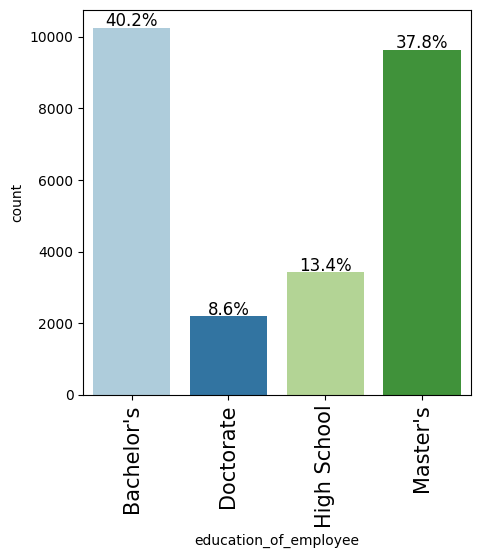

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)



*   40.2% of applicants had a bachelors degree, 37.8 had masters while the rest has High school or doctorate as highest qualification




### Observations on region of employment

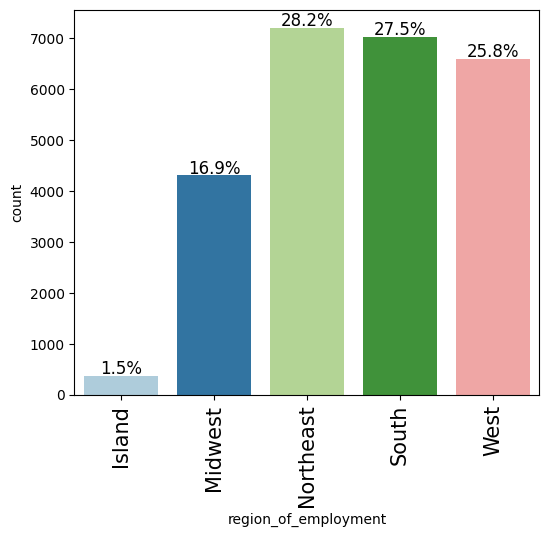

In [ ]:
labeled_barplot(data, "region_of_employment", perc=True) ## To plot labeled barplot for the region of employment column

*   Most request for employees came from the Northwest (28.2%), South (27.5%) and West (25.8%) followed by the Midwest (16.9%).




### Observations on job experience

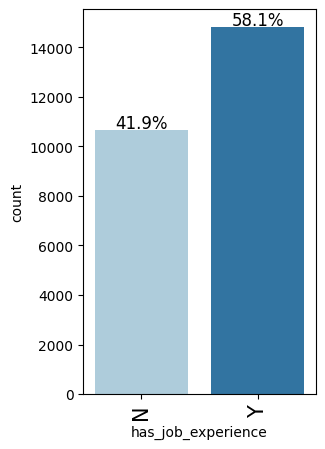

In [ ]:
labeled_barplot(data, "has_job_experience", perc=True) ## To plot labeled barplot for the job experience column



*   Most applicants had previous job experience (58.1%) while 41.9 had no prior job experience.




### Observations on no_of_employees

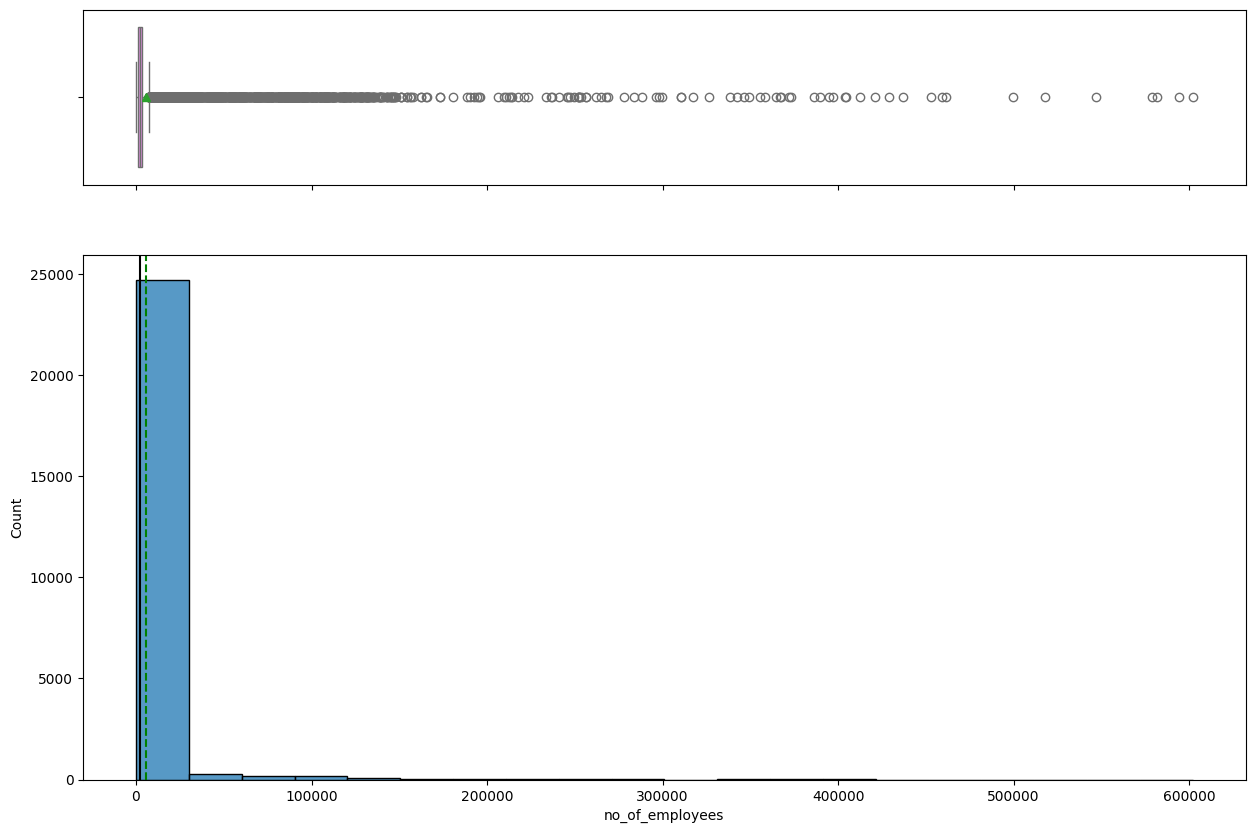

In [ ]:
histogram_boxplot(data, 'no_of_employees', bins = 20)



*   The distribution of no_of_employees is highly right-skewed, with most companies having relatively smaller employee counts and a few companies having extremely large workforces.
*   The boxplot indicates the presence of several outliers, suggesting significant variation in company sizes across the dataset.



### Observations on yr_of_estab

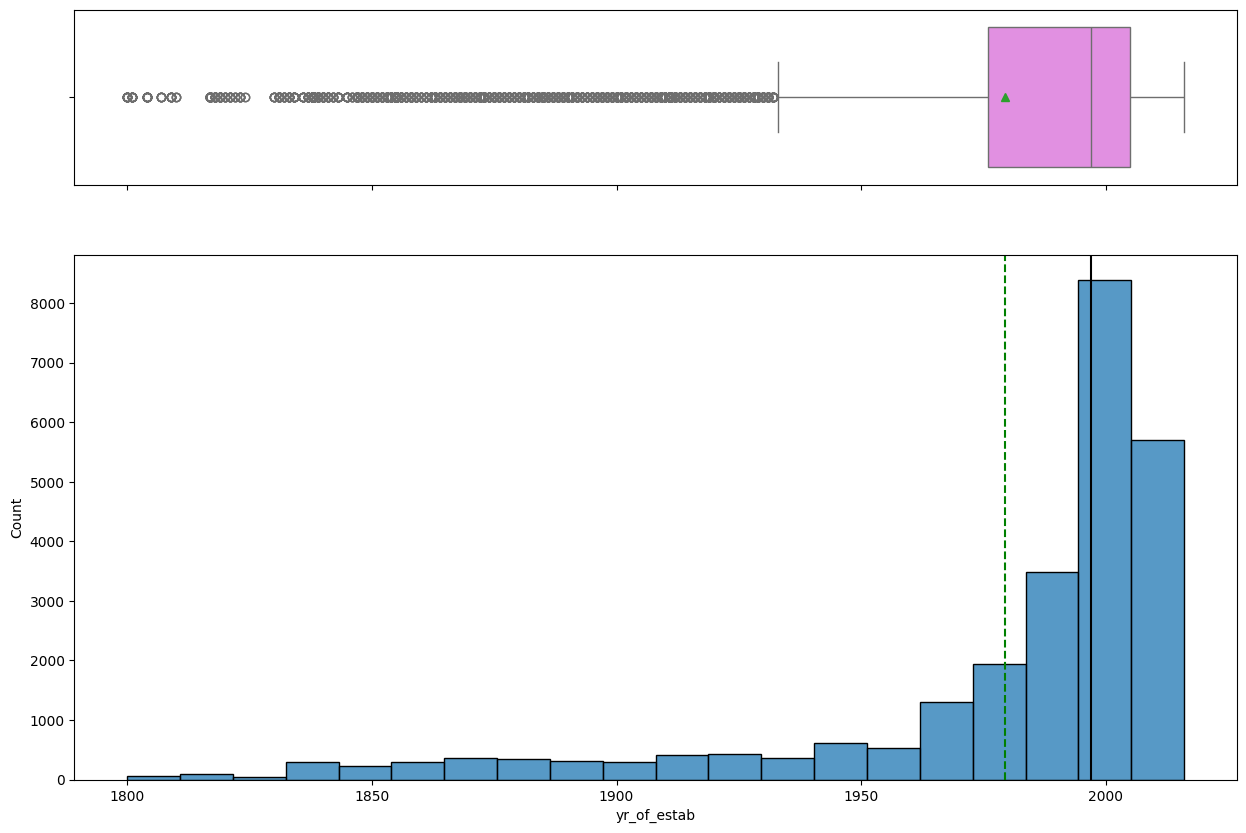

In [ ]:
histogram_boxplot(data, 'yr_of_estab', bins = 20) ## To plot histogram and boxplot for the year of establishment column



*   The distribution is heavily left-skewed, with most requests coming from companies established 2000 (about 8,000) and later (about 5,500) with median about 1998.

### Observations on full_time_position

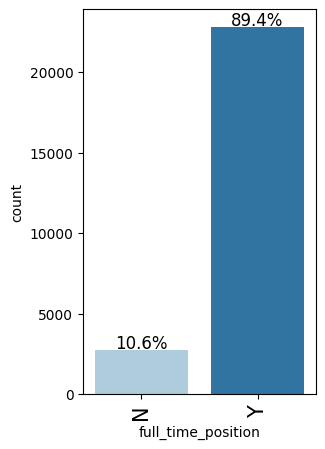

In [ ]:
labeled_barplot(data, "full_time_position", perc=True) ## To plot labeled barplot for the full time position column



*   89.4% of applications were for full time postions compared to 10.6% for non fulltime (part time) positions.



### Observations on case status

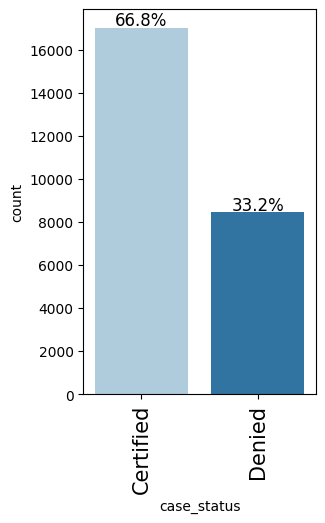

In [ ]:
labeled_barplot(data, "case_status", perc=True) ## To plot labeled barplot for the case status column

* 66.8% of applications were certified compared to 33.2% that were denied.

## Bivariate Analysis

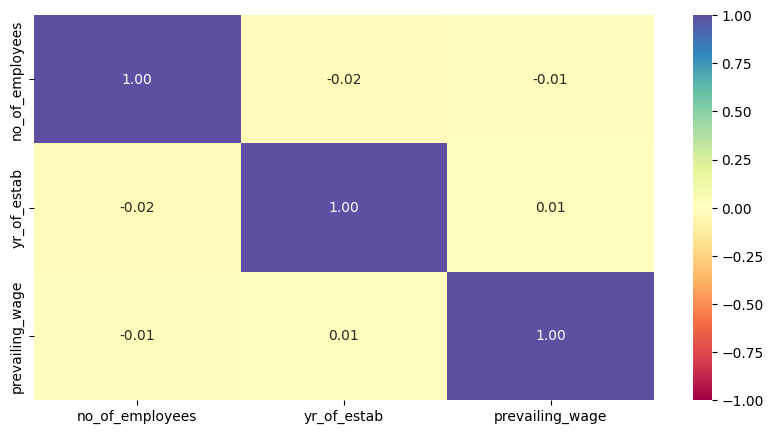

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()



*   There is no corelation between Number of Employees, Year of Establishment or Prevailing Wage



**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Let's find out if education has any impact on visa certification

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


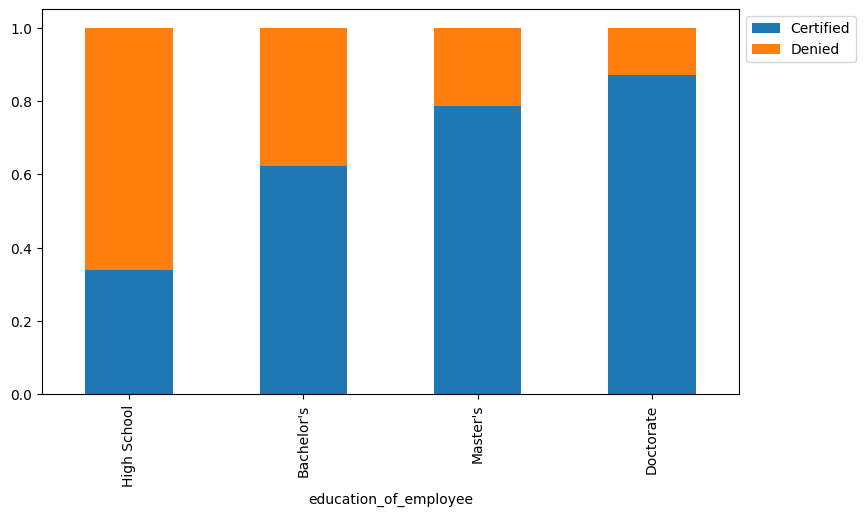

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")



*   Certification rates increase with education level.
*   Doctorate holders have the highest approval rates (>80%), followed by Master’s (>70%), Bachelor’s (~60%), while High School remains below 40%.



#### Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


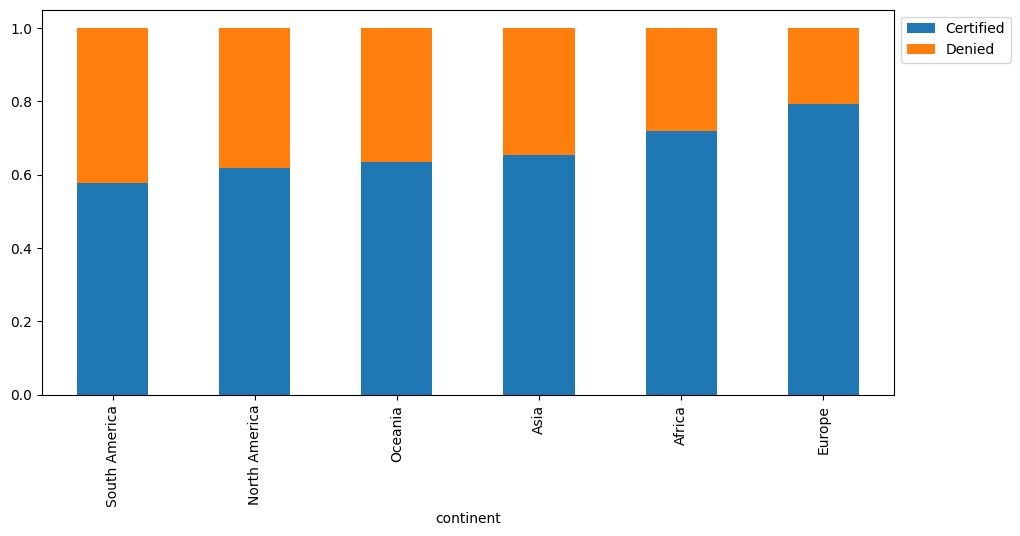

In [ ]:
stacked_barplot(data, "continent", "case_status") ## To plot the stacked barplot for continent and case status


*   Certification rates are highest for workers from Europe (~80%) and Africa (~70%), followed by Asia, Oceania and North America (~60%), and South America (<60%).





#### Let's see if having work experience has any influence over visa certification

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


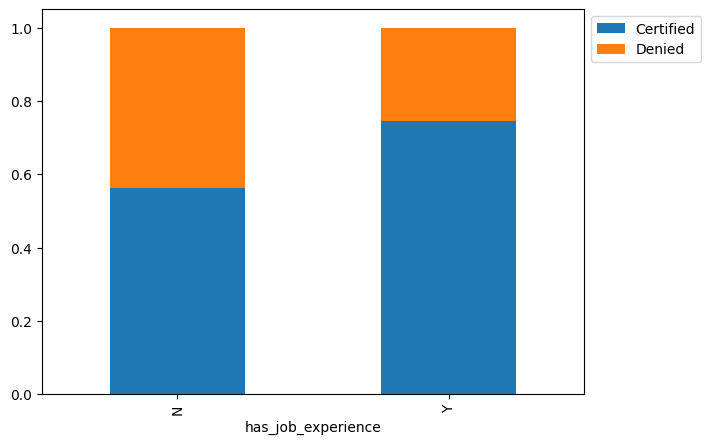

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status") ## To plot the stacked barplot for job experience and case status



*   More workers with job experience were certified (above 70%) compared to workers without job experience (below 60%).



#### Checking if the prevailing wage is similar across all the regions of the US

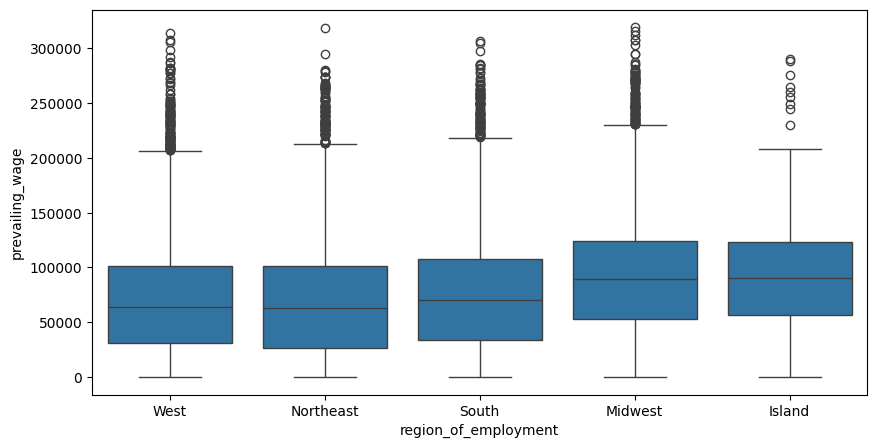

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()



*   The median wage across regions is below $100,000 with the highest being Island and Midwest, with the least being being the West.



#### Let's analyze the data and see if the visa status changes with the prevailing wage

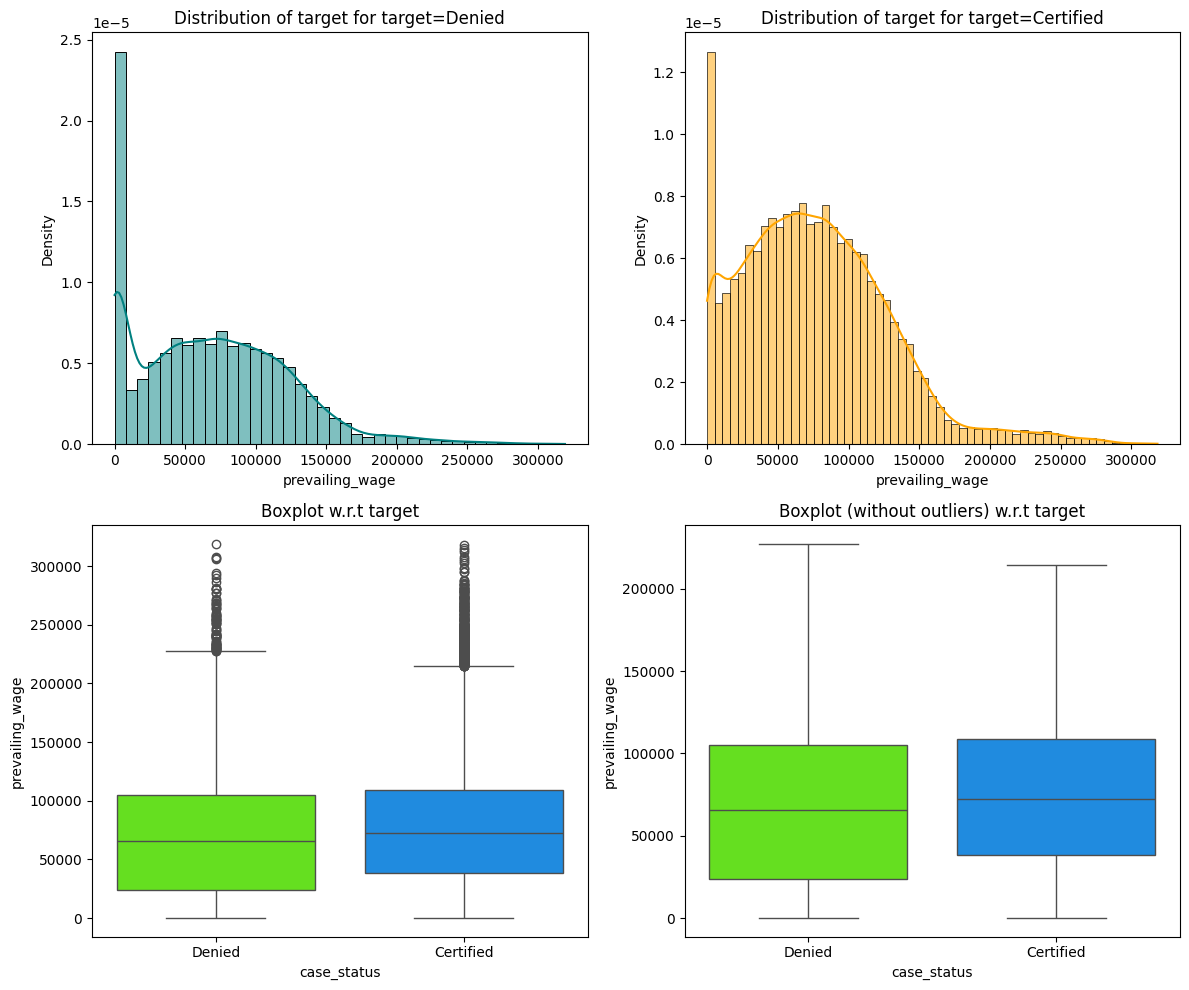

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")



*   Certified applications generally show slightly higher prevailing wages compared to denied applications, as seen from the boxplots and distributions.


#### Observations on no_of_employees and case_status

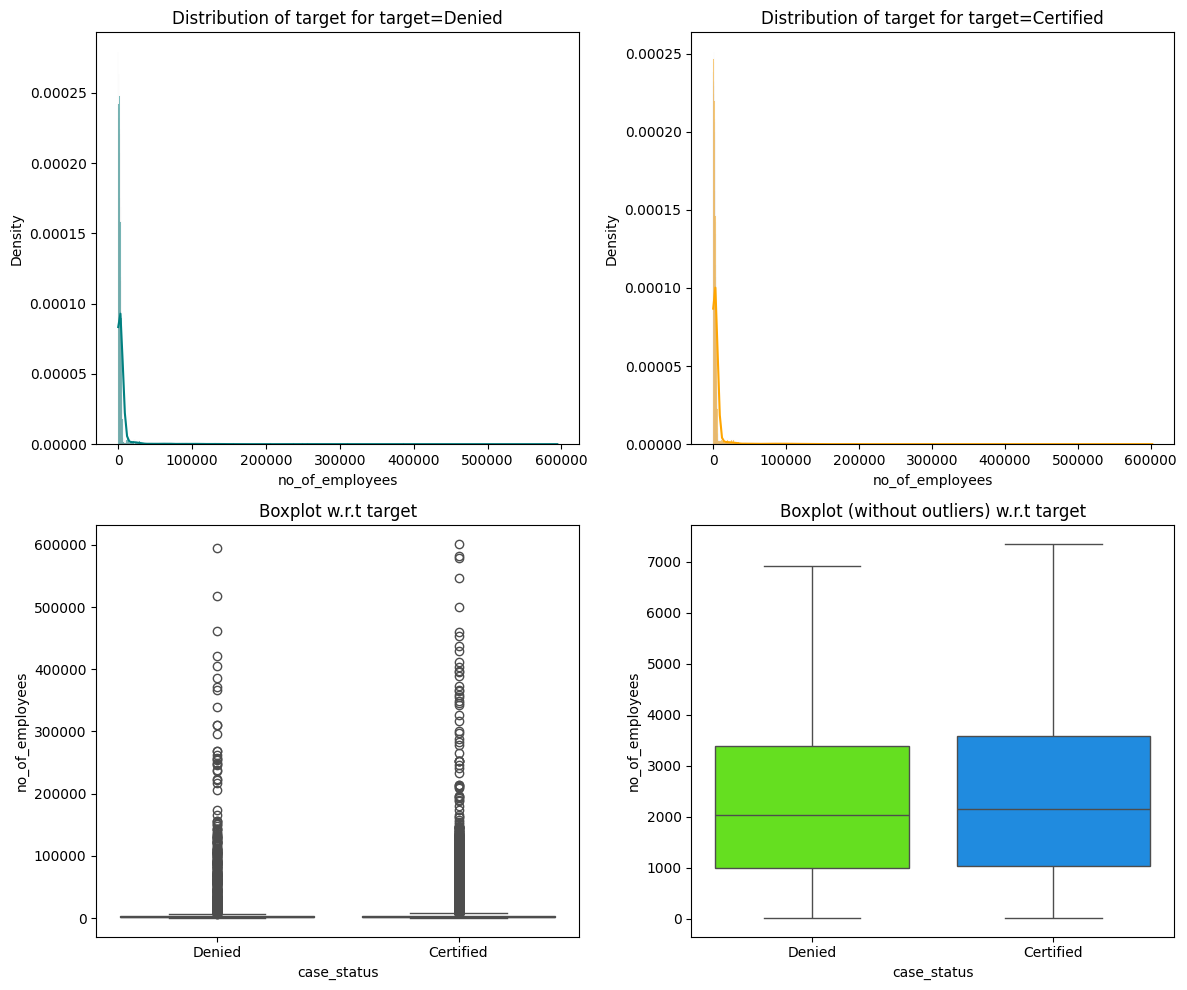

In [ ]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")  ## To plot the distribution plot wrt target for no of employees and case status



*   The median number of employees for both Certified and Denied cases is nearly the same at 2,100 cases approximately.




#### Observations on yr_of_estab and case_status

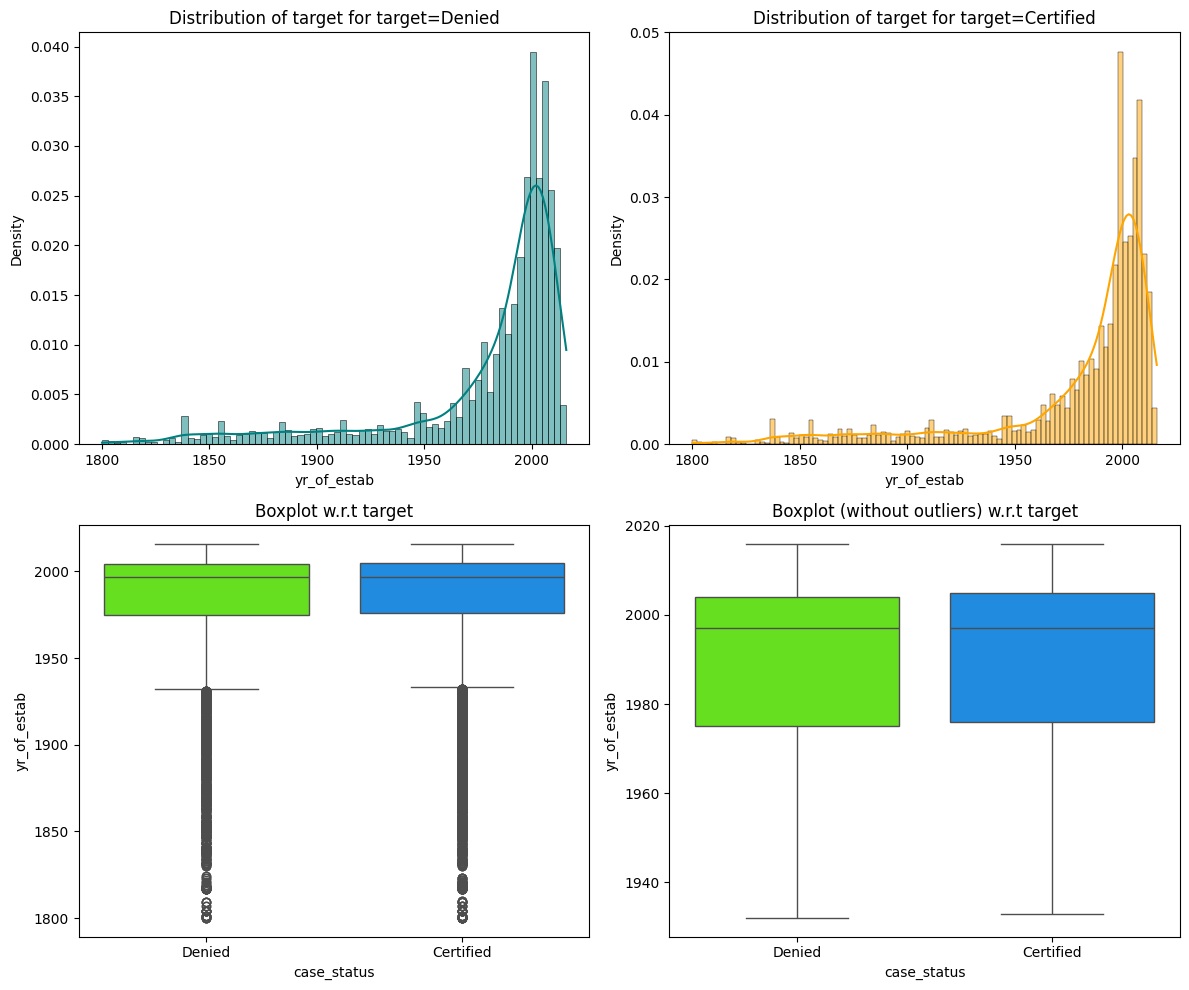

In [ ]:
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")  ## To plot the distribution plot wrt target for year of establishment and case status



*   The median year of establishment for both Certified and Denied cases is nearly the same at approximately 1997.



#### Let's find out if it has any impact on visa applications getting certified.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


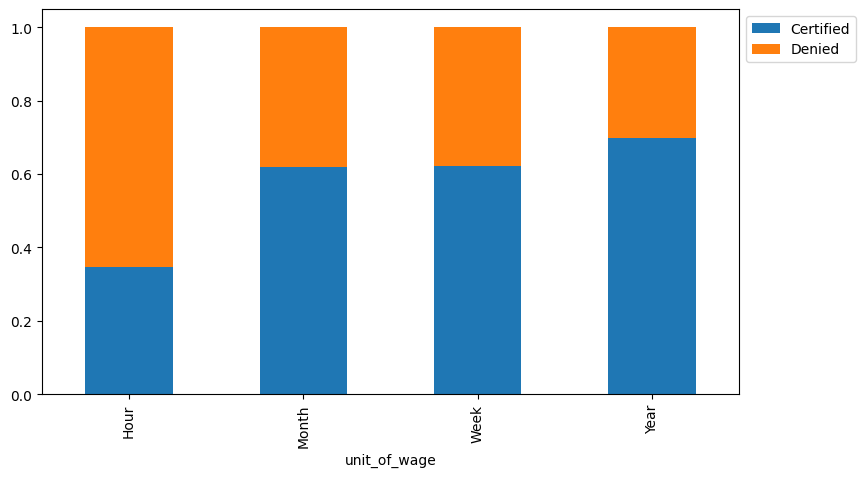

In [ ]:
stacked_barplot(data, "unit_of_wage", "case_status")  ## To plot the stacked barplot for unit of wage and case status



*   Certification rates increase as payment frequency decreases.
*   Yearly-paid applicants have the highest certification rate (~70%), followed by weekly and monthly (~62%), while hourly-paid applicants have the lowest (~35%).



#### Observations on full_time_position and case_status

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


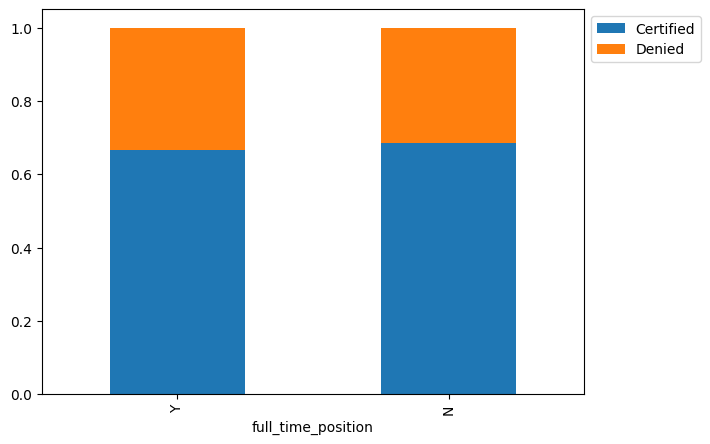

In [ ]:
stacked_barplot(data, "full_time_position", "case_status")  ## To plot the stacked barplot for full time position and case status



*   Workers in full-time (Y) and non–full-time (N) positions have nearly the same certification rate, at approximately 68%.



# **Data Pre-processing**

### Outlier Check

- Let's check for outliers in the data.

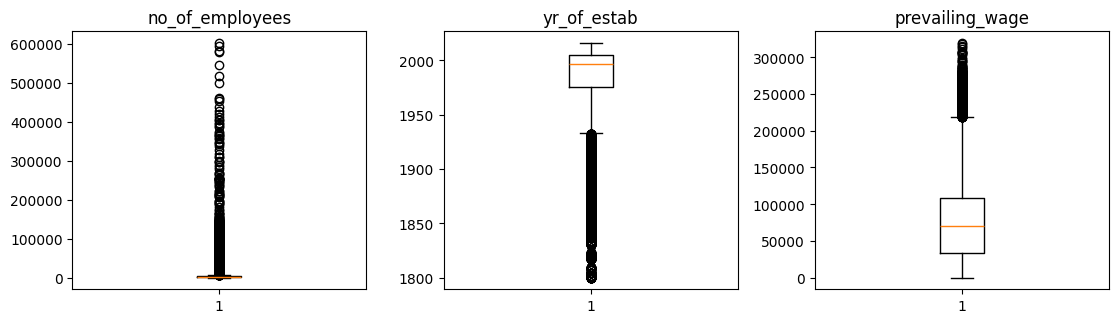

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()



*   The boxplots indicate the presence of significant outliers in no_of_employees, yr_of_estab, and prevailing_wage, suggesting high variability within the dataset.
*   no_of_employees and prevailing_wage are highly right-skewed, with a small number of companies and applications having exceptionally large values.
*   yr_of_estab contains several older establishments as outliers, while most companies appear to have been established more recently.





### Data Preparation for modeling

- We want to predict which visa will be certified.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [ ]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(["case_status"], axis=1)
y = data["case_status"]


X = pd.get_dummies(X, drop_first=True)
# X = X.astype(float)

# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 21)
Shape of the Validation set:  (5096, 21)
Shape of test set :  (5096, 21)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


# **Model Building**

## Model evaluation criterion

**Model can make wrong predictions as**:

1. Model predicts that the visa application will get certified but in reality, the visa application should get denied.
2. Model predicts that the visa application will not get certified but in reality, the visa application should get certified.

**Which case is more important?**
* Both the cases are important as:

* If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

* If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.


**How to reduce the losses?**

* `F1 Score` can be used a the metric for evaluation of the model, greater the F1  score higher are the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights so that model focuses equally on both classes.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Model Building - Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1, class_weight="balanced")))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, eval_metric="logloss")))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.989150179193873
Random Forest: 1.0
Adaboost: 0.8204269947530306
Gradient Boosting: 0.8291218182658106
XGBoost: 0.8963229453814886

Validation Performance:

Bagging: 0.7736516357206012
Random Forest: 0.8049978941457251
Adaboost: 0.8180081855388813
Gradient Boosting: 0.826637008202419
XGBoost: 0.8079119654547987


Based on performance on validation and generalization, the best 3 models are:

*   Gradient Boosting
*   Adaboost and
*   XGBoost

XGBoost shows some degree of overfitting, while Random Forest and Bagging are overfitting on the validation set.

## Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 10210
Before Oversampling, counts of label 'Denied': 5078 

After Oversampling, counts of label 'Certified': 10210
After Oversampling, counts of label 'Denied': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, eval_metric="logloss")))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))  ## To build models on oversampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9875473741201949
Random Forest: 0.9999510260051913
Adaboost: 0.8005498403689252
Gradient Boosting: 0.8072434234901815
XGBoost: 0.8708686342053813

Validation Performance:

Bagging: 0.7665171898355755
Random Forest: 0.7965442764578834
Adaboost: 0.8195334879279771
Gradient Boosting: 0.8173049645390071
XGBoost: 0.8129304286718201


Based on performance on validation and generalization, the best 3 models are:

*   Gradient Boosting
*   Adaboost and
*   XGBoost

XGBoost shows some degree of overfitting, while Random Forest and Bagging are overfitting on the validation set.

## Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 10210
Before Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, counts of label 'Certified': 5078
After Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, eval_metric="logloss")))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))  ## To build models on oversampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9875473741201949
Random Forest: 0.9999510260051913
Adaboost: 0.8005498403689252
Gradient Boosting: 0.8072434234901815
XGBoost: 0.8708686342053813

Validation Performance:

Bagging: 0.7057046979865772
Random Forest: 0.7417218543046358
Adaboost: 0.765990884802766
Gradient Boosting: 0.776595744680851
XGBoost: 0.7459304181295883


Based on performance on validation and generalization, the best 3 models are:

*   Gradient Boosting
*  Adaboost and
*   XGBoost

XGBoost shows some degree of overfitting, while Random Forest and Bagging are overfitting on the validation set.

# **Model Performance Improvement**


- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


## Hyperparameter Tuning - AdaBoost Classifier

In [ ]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, param_grid, scoring=acc_scorer, cv=5, n_jobs=-1)  ## Corrected to use param_grid
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

CPU times: user 5.49 s, sys: 114 ms, total: 5.6 s
Wall time: 1min 36s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.05, n_estimators=np.int64(100),
                   random_state=1)

### Checking model performance on training set

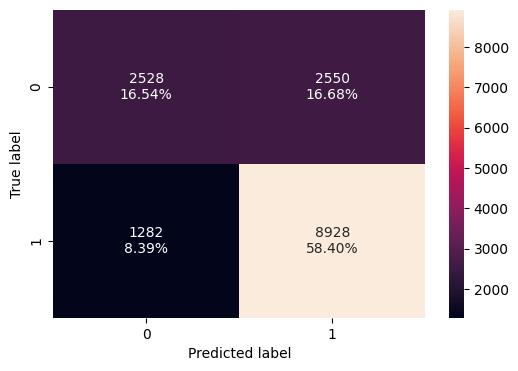

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_train, y_train)  ## To plot the confusion matrix for the Adaboost Classifier on the training set

In [ ]:
abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)  ## To get the perfromance metrics for the Adaboost Classifier on the training set
abc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749346,0.874437,0.777836,0.823312


### Checking model performance on validation set

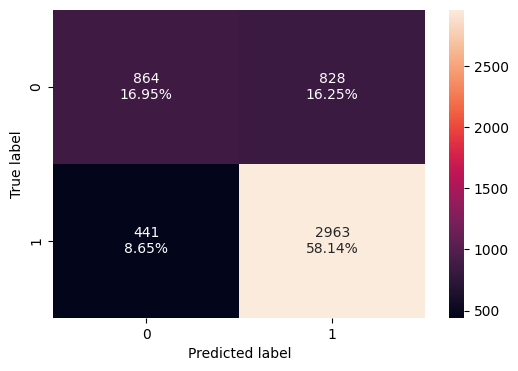

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_val, y_val)  ## To plot the confusion matrix for the Adaboost Classifier on the validation set

In [ ]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(abc_tuned, X_val, y_val)  ## To get the perfromance metrics for the Adaboost Classifier on the validation set
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.750981,0.870447,0.781588,0.823628




*  The model shows consistent performance between the training and validation sets, with an accuracy of approx. 75%, recall of approx. 87% and nearly identical F1 scores of 82%, indicating that the model is well-generalized and not overfitting.


## Hyperparameter Tuning - Gradient Boosting Classifier

In [55]:
%%time
# Choosing the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, param_grid, scoring=acc_scorer, cv=5, n_jobs=-1)  ## Corrected to use param_grid
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

CPU times: user 5.06 s, sys: 568 ms, total: 5.63 s
Wall time: 6min 6s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), random_state=1,
                           subsample=0.7)

### Checking model performance on training set

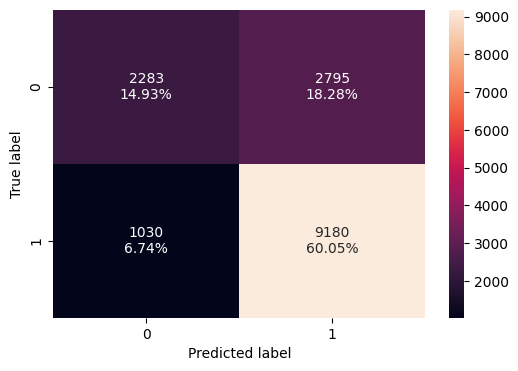

In [56]:
confusion_matrix_sklearn(gbc_tuned, X_train, y_train)  ## To plot the confusion matrix for the Gradient Boosting Classifier on the training set

In [57]:
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)  ## To get the perfromance metrics for the Gradient Boosting Classifier on the training set
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749804,0.899119,0.766597,0.827586


### Checking model performance on validation set

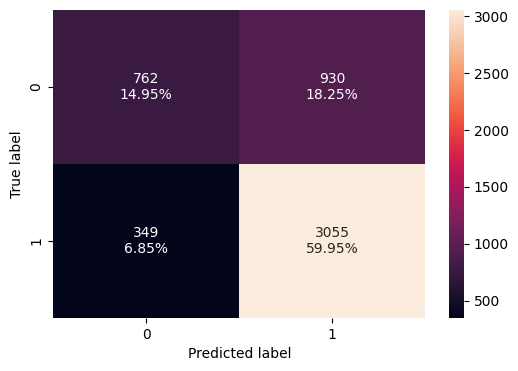

In [58]:
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)  ## To plot the confusion matrix for the Gradient Boosting Classifier on the validation set

In [59]:
gbc_tuned_model_val_perf = model_performance_classification_sklearn(gbc_tuned, X_val, y_val)  ## To get the perfromance metrics for the Gradient Boosting Classifier on the validation set
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749019,0.897474,0.766625,0.826905




*   The model shows consistent performance between the training and validation sets, with an accuracy of approx. 75%, recall of approx. 90% and nearly identical F1 scores of 83%, indicating that the model is well-generalized and not overfitting.




## Hyperparameter Tuning - XGBoost Classifier

In [63]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, param_grid, scoring=acc_scorer, cv=5, n_jobs=-1)  ## To define the grid search object
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

CPU times: user 2.96 s, sys: 246 ms, total: 3.2 s
Wall time: 1min 37s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, ...)

### Checking model performance on training set

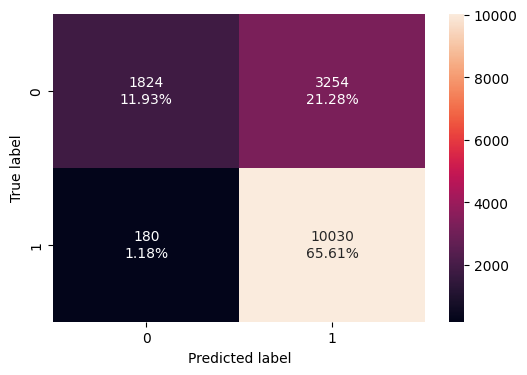

In [64]:
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)  ## To plot the confusion matrix for the XGBoost Classifier on the training set

In [65]:
xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)  ## To get the perfromance metrics for the XGBoost Classifier on the training set
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.775379,0.98237,0.755044,0.853835


### Checking model performance on validation set

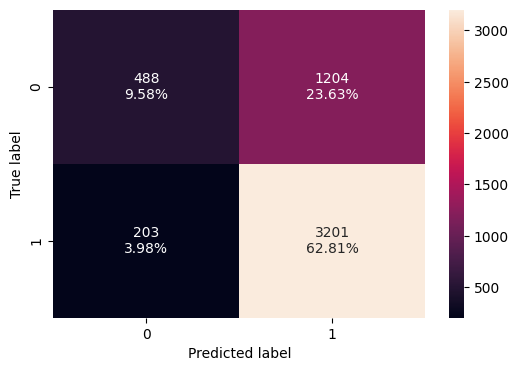

In [75]:
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)  ## To plot the confusion matrix for the XGBoost Classifier on the validation set

In [76]:
xgb_tuned_model_val_perf = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)  ## To get the perfromance metrics for the XGBoost Classifier on the validation set
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.723901,0.940364,0.726674,0.819823




*   There is a drop in performance between the training and validation sets compared to the other two models. The model is generalized and moderately overfitting.



# **Model Comparison and Final Model Selection**

## Comparing all models

In [67]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        abc_tuned_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.749346,0.749804,0.775379
Recall,0.874437,0.899119,0.982370
Precision,0.777836,0.766597,0.755044
F1,0.823312,0.827586,0.853835


In [71]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        abc_tuned_model_val_perf.T,
        gbc_tuned_model_val_perf.T,
        xgb_tuned_model_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.750981,0.749019,0.723901
Recall,0.870447,0.897474,0.940364
Precision,0.781588,0.766625,0.726674
F1,0.823628,0.826905,0.819823


The Tuned Gradient Boost Classifier is recommended as the final model for the following reasons:

- It achieved the highest validation F1 score of 0.8269 among all evaluated models, making it the strongest overall performer based on the primary selection criterion.

- The model demonstrates strong generalization ability, as the training F1 score (0.8276) is nearly identical to the validation F1 score (0.8269), indicating minimal overfitting.

- While the tuned XGBoost model achieved the highest recall, the Tuned Gradient Boost Classifier provided a better overall balance between precision and recall, resulting in the best F1 score on the validation dataset.


In [77]:
# Let's check the performance on test set
print("Test performance comparison:")
model_performance_classification_sklearn(gbc_tuned, X_test, y_test)

Test performance comparison:


,Accuracy,Recall,Precision,F1
0,0.737441,0.891892,0.757863,0.819433


### Checking Gradient Boost tuned model performance on test set

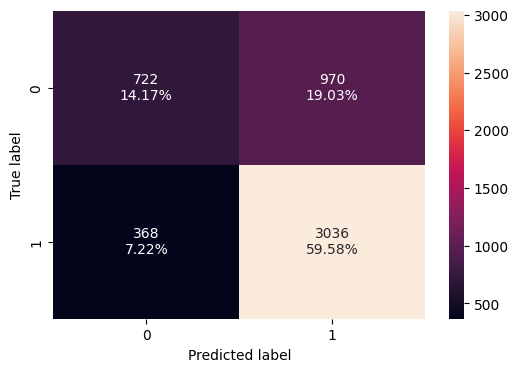

In [78]:
confusion_matrix_sklearn(gbc_tuned, X_test, y_test)

In [79]:
gbc_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
gbc_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.716248,0.944183,0.719016,0.816358


- The Tuned Gradient Boost Classifier continues to demonstrate stable performance across the training, validation, and test datasets, indicating good generalization and minimal overfitting.

- On the test dataset, the model achieved an F1 score of 0.8164 while recall improved to 0.9442, showing strong ability to correctly identify certified visa applications.

- Although precision and overall accuracy decreased slightly on the test data, the high recall and stable F1 score confirm that the model remains a strong candidate for production deployment.



## Important features of the final model

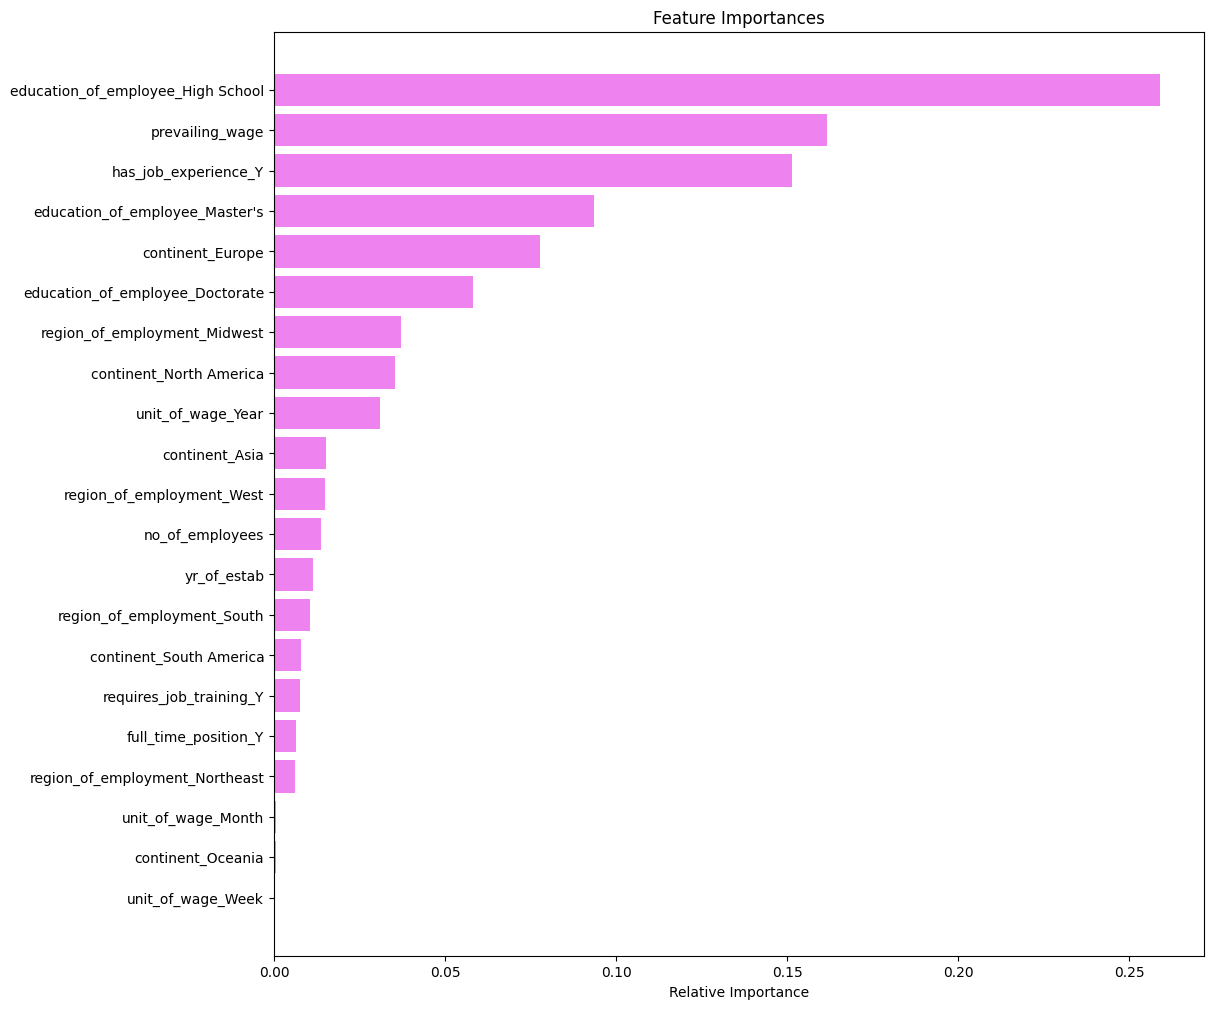

In [81]:
feature_names = X_train.columns
importances = gbc_tuned.feature_importances_  ## Complete the code to get the feature importances of the best model
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Actionable Insights and Recommendations**

- The Tuned Gradient Boost Classifier achieved the best overall performance, demonstrating strong balance between precision and recall while maintaining stable results across training, validation, and test datasets.

- Education level, prevailing wage, and prior work experience were identified as the most influential factors affecting visa certification outcomes.

- The model can support faster and more data-driven visa screening by helping prioritize high-probability certification cases and improving decision-making efficiency.

- Employers may improve approval likelihood by offering competitive wages and targeting applicants with stronger educational and professional backgrounds.

- Continuous monitoring and periodic retraining of the model are recommended to maintain performance as labor market conditions evolve.   



___